

```
# author: puru panta (purupanta@uky.edu)
# date: 11/30/2024
# filename: PredictMLDL_Stacked
```



**STEP1: Install and Import libraries required**

In [1]:
!pip install --upgrade tf-keras
!pip install --upgrade tensorflow
!pip install --upgrade scikit-learn imbalanced-learn
!pip install xlsxwriter
!pip install --upgrade scikeras # Upgrade scikeras
!pip install lightgbm
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 68.0 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.0
    Uninstalling tensorflow-2.18.0:
      Successfully uninstalled tensorflow-2.18.0
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.18.0
    Uninstalling tf_keras-2.18.0:
      Successfully uninstalled tf_keras-2.18.0
ERROR: pip's dep

In [2]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, fbeta_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import make_classification

In [3]:
# Mounting google drive if it is already not mounted
def LoadGoogleDrive(googleDriveDir):
  # Link Google Drive
  import os
  # Check if Google Drive is already mounted
  if not os.path.exists(googleDriveDir + "/MyDrive"):
      print("Mounting Google Drive...")
      from google.colab import drive
      drive.mount(googleDriveDir)
  else:
      print("Google Drive is already mounted!")

**STEP2: Load google-drive, and data**[link text](https://)

In [4]:
# Mount the google drive
googleDriveFolder = "/content/drive"
LoadGoogleDrive(googleDriveFolder)
# ip_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/ip_data/hints6_public.xlsx"
ip_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/op_data/op_hints6_public_cleaned.xlsx"
ip_sheet_name = "hints6_public_cleaned" # "hints6_public_cleaned_diabetic" # "hints6_public"
colsToLoad = ["FreqGoProvider", "GeneralHealth", "Deaf", "MedConditions_Diabetes","MedConditions_HighBP", "MedConditions_HeartCondition","MedConditions_LungDisease", "MedConditions_Depression","AverageSleepNight","AverageTimeSitting", "EverHadCancer", "Age", "BirthGender", "BMI", "smokeStat", "PHQ4", "WeeklyMinutesModerateExercise", "AvgDrinksPerWeek"];

print("Ip File Path: " + ip_file_path + "\t SheetName: " + ip_sheet_name)

# Loading cleaded excel data
df_orig = pd.read_excel(ip_file_path, sheet_name=ip_sheet_name, usecols=colsToLoad)
df = df_orig.copy()

predictors = df.drop(columns=['MedConditions_HeartCondition']).columns
target = df['MedConditions_HeartCondition'].name

print(f"df_orig.shape: {df_orig.shape}")

Mounting Google Drive...
Mounted at /content/drive
Ip File Path: /content/drive/MyDrive/Colab Notebooks/P_HINTS6/op_data/op_hints6_public_cleaned.xlsx	 SheetName: hints6_public_cleaned
df_orig.shape: (4875, 18)


**STEP3: Train-test split Scale, SMOTEENN**

In [5]:
def TrainTestSplit(df):
  # AllCols = ["FreqGoProvider", "GeneralHealth", "Deaf", "MedConditions_Diabetes", "MedConditions_HighBP", "MedConditions_HeartCondition", "MedConditions_LungDisease", "MedConditions_Depression", "AverageSleepNight", "AverageTimeSitting", "EverHadCancer", "Age", "BirthGender", "BMI", "smokeStat", "PHQ4", "WeeklyMinutesModerateExercise", "AvgDrinksPerWeek"];

  # Define features (X) and target (y)
  X = df.drop(columns=['MedConditions_HeartCondition'])
  y = df['MedConditions_HeartCondition']

  # Convert categorical variables to numerical using one-hot encoding

  # Perform train-test split (80% train, 20% test)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )
  return X_train, X_test, y_train, y_test

# Step 2: Scale features using StandardScaler
def ScaleTrainData(X_train, X_test):
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)   # Fit ONLY on training data
  X_test_scaled = scaler.transform(X_test)         # Use same scaler on test data
  return X_train_scaled, X_test_scaled, scaler

# Step 3: Apply SMOTE only to training data
def ApplySMOTE(X_train, y_train):
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print("Original shape:", y_train.shape)
    print("Resampled shape:", y_res.shape)
    return X_res, y_res

# Step 4: Apply ApplySMOTEENN only to training data
def ApplySMOTEENN(X_train, y_train):
  sm = SMOTEENN(random_state=42)
  X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

  print("Original dataset shape:", y_train.shape)
  print("Resampled dataset shape:", y_train_res.shape)
  return X_train_res, y_train_res

# Step 5: Apply ApplyADASYN only to training data
def ApplyADASYN(X_train, y_train):
  from imblearn.over_sampling import ADASYN
  adasyn = ADASYN(random_state=42)
  X_res, y_res = adasyn.fit_resample(X_train, y_train)
  print("Original training set shape:", y_train.shape)
  print("Resampled training set shape:", y_res.shape)
  return X_res, y_res

# Step 6: Apply ApplyBorderlineSMOTE only to training data
def ApplyBorderlineSMOTE(X_train, y_train, kind='borderline-1'):
  from imblearn.over_sampling import BorderlineSMOTE
  sm = BorderlineSMOTE(kind=kind, random_state=42)
  X_res, y_res = sm.fit_resample(X_train, y_train)
  print("Original shape:", y_train.shape)
  print("Resampled shape:", y_res.shape)
  return X_res, y_res

In [6]:
X_train, X_test, y_train, y_test = TrainTestSplit(df)

In [7]:
X_train_res, y_train_res = ApplySMOTEENN(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplyBorderlineSMOTE(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplyADASYN(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplySMOTE(X_train.copy(), y_train.copy())

Original dataset shape: (3900,)
Resampled dataset shape: (5510,)


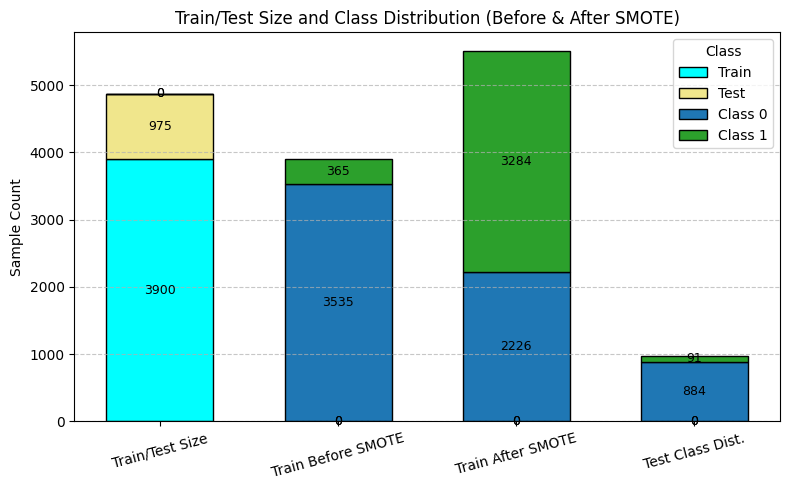

In [8]:
# Prepare data for plotting
plot_data = {
    'Train/Test Size': {
        'Train': len(y_train),
        'Test': len(y_test)
    },
    'Train Before SMOTE': {
        'Class 0': (y_train == 0).sum(),
        'Class 1': (y_train == 1).sum()
    },
    'Train After SMOTE': {
        'Class 0': (y_train_res == 0).sum(),
        'Class 1': (y_train_res == 1).sum()
    },
    'Test Class Dist.': {
        'Class 0': (y_test == 0).sum(),
        'Class 1': (y_test == 1).sum()
    }
}
# Define custom colors
class_colors = {
    'Class 0': '#1f77b4',  # blue
    'Class 1': '#2ca02c',   # green
    'Train': '#00FFFF',    # cyan
    'Test': '#F0E68C'      # dim yellow
}

# Convert to DataFrame
df_plot = pd.DataFrame(plot_data).T.fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_plot.index))
bar_width = 0.6
bottom = np.zeros(len(x))

# Plot each class
for cls in df_plot.columns:
    heights = df_plot[cls].values
    bars = ax.bar(x, heights, bottom=bottom, width=bar_width, label=cls, edgecolor='black', color=class_colors.get(cls, 'gray'))

    # Add number to each segment
    for i, height in enumerate(heights):
        ax.text(x[i], bottom[i] + height / 2, str(int(height)),
                ha='center', va='center', fontsize=9, color='black')

    bottom += heights

# Axes and layout
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=15)
ax.set_title('Train/Test Size and Class Distribution (Before & After SMOTE)')
ax.set_ylabel('Sample Count')
ax.legend(title='Class', loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
# Step 4: If needed, reshape the target arrays
y_train = y_train.to_numpy().ravel() if hasattr(y_train, 'to_numpy') else y_train.ravel()
y_test = y_test.to_numpy().ravel() if hasattr(y_test, 'to_numpy') else y_test.ravel()

In [10]:
# Train/Test assignments
X_train = X_train_res.copy();
y_train = y_train_res.copy();
X_test = X_test.copy();
y_test = y_test.copy();

In [11]:
X_train, X_test, scaler = ScaleTrainData(X_train.copy(), X_test.copy())

**STEP8: Prediction Starts**

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np

**1. Stacked Model with dynamic routing**

In [13]:
# Train/Test assignments
X_train_stacked = X_train.copy()
y_train_stacked = y_train.copy()
X_test_stacked = X_test.copy()
y_test_stacked = y_test.copy()

In [14]:
# Generating out-of-fold (oof) meta-features
def generate_oof_meta_features(X, y, base_models_dict, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    meta_features = np.zeros((X.shape[0], len(base_models_dict)))
    best_model_labels = np.zeros(X.shape[0], dtype=int)

    for train_idx, val_idx in skf.split(X, y):
        correct_matrix = np.zeros((len(val_idx), len(base_models_dict)))
        for j, (name, model) in enumerate(base_models_dict.items()):
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            meta_features[val_idx, j] = model.predict_proba(X[val_idx])[:, 1]
            correct_matrix[:, j] = (preds == y[val_idx]).astype(int)
        best_model_labels[val_idx] = np.argmax(correct_matrix, axis=1)

    # Ensure all labels are within range
    best_model_labels = np.clip(best_model_labels, 0, len(base_models_dict) - 1)
    return meta_features, best_model_labels



In [ ]:
# STEP 1: Define Base Models
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

base_models = {
    'rf': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'lr': LogisticRegression(solver='liblinear', random_state=42),
    'svm': SVC(kernel='poly', probability=True, class_weight='balanced', random_state=42),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'gbm': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'xgb': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    )
}


In [ ]:
# Start timing
start_time = time.time()

##### STEP1:
##### Generate router training data using OOF: Predicted probabilities and Best model
meta_X_router, best_model_labels = generate_oof_meta_features(X_train_stacked, y_train_stacked, base_models)

print("Meta-features shape:", meta_X_router.shape)
print("Best model labels shape:", best_model_labels.shape)

# Train final base models on full training set
trained_base_models = {name: model.fit(X_train_stacked, y_train_stacked) for name, model in base_models.items()}

# Train router
router = RandomForestClassifier(n_estimators=100, random_state=42)
router.fit(meta_X_router, best_model_labels)


#####STEP2:
# Prepare test meta-features
meta_X_test_router = np.column_stack([
    model.predict_proba(X_test_stacked)[:, 1] for model in trained_base_models.values()
])

# Get router’s selected model for each sample
selected_model_indices = router.predict(meta_X_test_router)
model_names = list(trained_base_models.keys())

# Predict using selected model per test sample
final_preds = []
final_probs = []
for i, idx in enumerate(selected_model_indices):
    model = trained_base_models[model_names[idx]]
    pred = model.predict(X_test_stacked[i].reshape(1, -1))[0]
    prob = model.predict_proba(X_test_stacked[i].reshape(1, -1))[0][1]
    final_preds.append(pred)
    final_probs.append(prob)

final_preds = np.array(final_preds)
final_probs = np.array(final_probs)

# Stop timing
end_time = time.time()
# Calculate execution time
execution_time = end_time - start_time
print(f"Total execution time: {execution_time:.2f} seconds")

#####STEP3:
accuracy = accuracy_score(y_test_stacked, final_preds)
roc_auc = roc_auc_score(y_test_stacked, final_probs)
print(f"Dynamic Routing Accuracy: {accuracy:.2f}")
print(f"Dynamic Routing AUC-ROC: {roc_auc:.2f}")
print(classification_report(y_test, final_preds))

# Plot ROC
fpr, tpr, _ = roc_curve(y_test, final_probs)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stacking ensemble with Dynamic Routing ROC Curve')
plt.legend()
plt.show()

NameError: name 'time' is not defined